In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

os.makedirs("graficas", exist_ok=True)

df = pd.read_excel("Dataset_fusionado_limpio.xlsx")

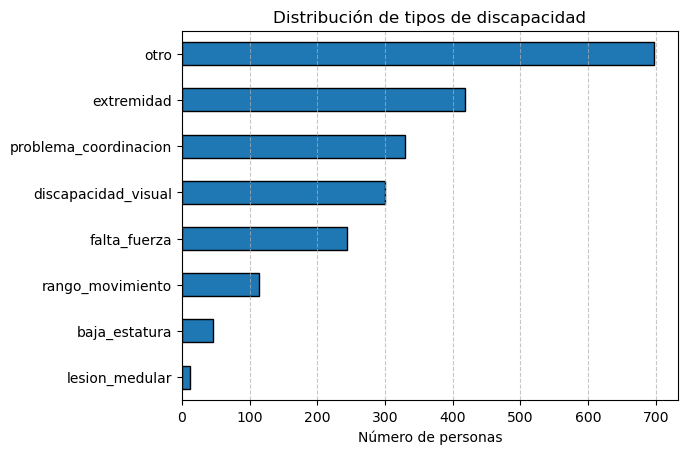

In [2]:
# -- Distribución de discapacidades --

cols = [
    'discapacidad_visual','problema_coordinacion','falta_fuerza',
    'extremidad','lesion_medular','rango_movimiento',
    'baja_estatura','otro'
]

data = df[cols].sum().sort_values()

ax = data.plot(
    kind="barh",
    edgecolor="black",
    linewidth=1
)

ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.7)

plt.title("Distribución de tipos de discapacidad")
plt.xlabel("Número de personas")

plt.savefig("graficas/distribucion_discapacidad.png", dpi=300, bbox_inches="tight")

plt.show()

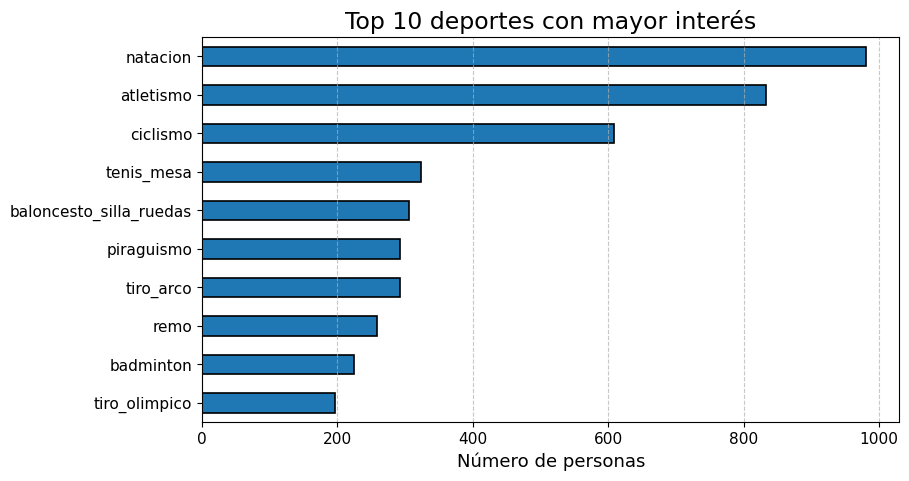

In [3]:
# -- Distribución de discapacidades --

cols_deportes = [
'atletismo','badminton','baloncesto_silla_ruedas','boccia','ciclismo',
'escalada','esgrima_silla_ruedas','futbol_ciegos','goalball','powerlifting',
'hipica','judo','natacion','piraguismo','remo','rugby_silla_ruedas',
'taekwondo','tenis_mesa','tenis_silla_ruedas','tiro_arco','tiro_olimpico',
'triatlon','voleibol_sentado','biatlon','curling_silla_ruedas',
'esqui_alpino','esqui_fondo','hockey_hielo','snowboard'
]

top_deportes = df[cols_deportes].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))

top_deportes.sort_values().plot(
    kind="barh",
    ax=ax,
    edgecolor="black",
    linewidth=1.2
)

ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.7)

ax.set_title("Top 10 deportes con mayor interés", fontsize=17)
ax.set_xlabel("Número de personas", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

plt.savefig("graficas/top_10_deportes.png", dpi=300, bbox_inches="tight")

plt.show()

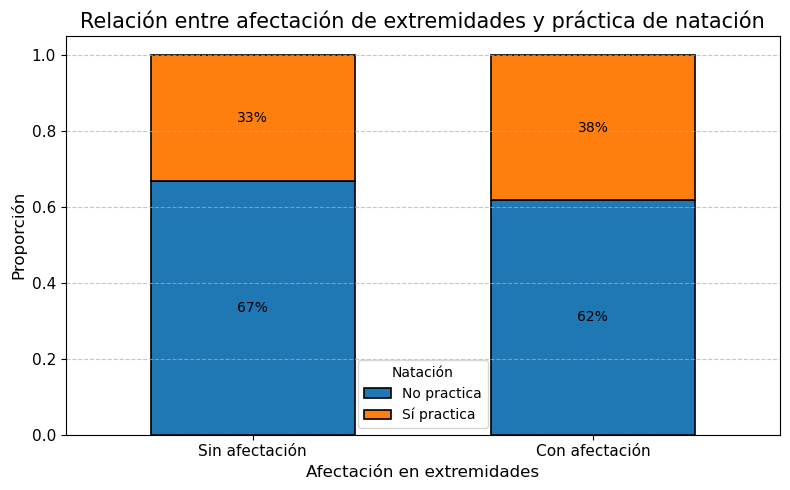

In [4]:
# -- Relación entre afectación de extremidades y práctica de natación (apilado) --

tabla = pd.crosstab(df["extremidad"], df["natacion"], normalize="index")

tabla.index = ["Sin afectación", "Con afectación"]
tabla.columns = ["No practica", "Sí practica"]

fig, ax = plt.subplots(figsize=(8, 5))

tabla.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    edgecolor="black",
    linewidth=1.2,
    width=0.6
)

ax.set_title("Relación entre afectación de extremidades y práctica de natación", fontsize=15)
ax.set_xlabel("Afectación en extremidades", fontsize=12)
ax.set_ylabel("Proporción", fontsize=12)
ax.tick_params(axis="both", labelsize=11)
ax.set_xticklabels(tabla.index, rotation=0)
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.7)
ax.legend(title="Natación")

# Etiquetas de porcentaje dentro de cada segmento
for contenedor in ax.containers:
    etiquetas = []
    for barra in contenedor:
        altura = barra.get_height()
        etiquetas.append(f"{altura:.0%}" if altura > 0.03 else "")
    ax.bar_label(contenedor, labels=etiquetas, label_type="center", fontsize=10)

plt.tight_layout()

plt.savefig("graficas/relacion_extremidades_natacion_apilado.png", dpi=300, bbox_inches="tight")
plt.show()

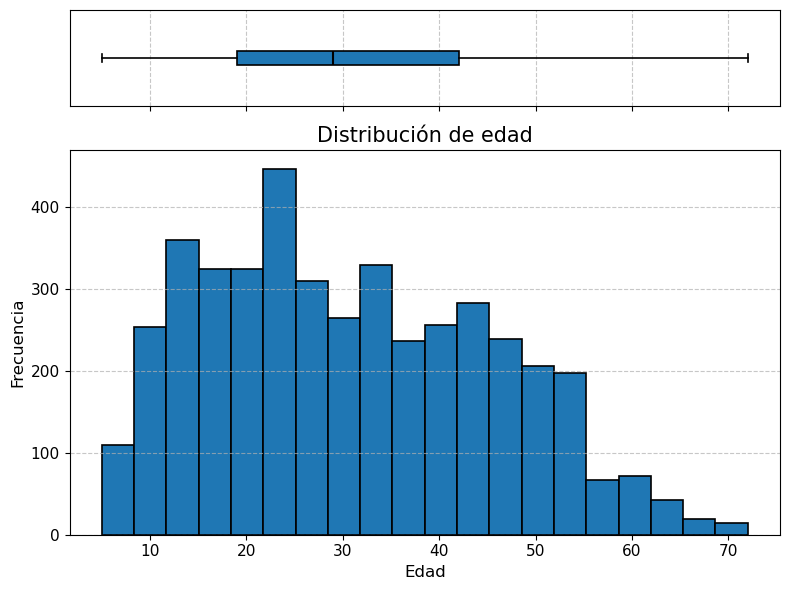

In [5]:
# -- Distribución de edad (histograma + box plot) --

df_filtrado = df[(df["edad"] >= 5) & (df["edad"] <= 100)].copy()

fig, (ax_box, ax_hist) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    gridspec_kw={"height_ratios": [1, 4]},
    sharex=True
)

# Box plot superior
ax_box.boxplot(
    df_filtrado["edad"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(edgecolor="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, markeredgecolor='black')
)
ax_box.set_yticks([])
ax_box.set_xlabel("")
ax_box.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.7)

# Histograma inferior
ax_hist.hist(
    df_filtrado["edad"],
    bins=20,
    edgecolor="black",
    linewidth=1.2
)
ax_hist.set_title("Distribución de edad", fontsize=15)
ax_hist.set_xlabel("Edad", fontsize=12)
ax_hist.set_ylabel("Frecuencia", fontsize=12)
ax_hist.tick_params(axis="both", labelsize=11)
ax_hist.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.7)

plt.tight_layout()

plt.savefig("graficas/distribucion_edad_boxplot_hist.png", dpi=300, bbox_inches="tight")
plt.show()

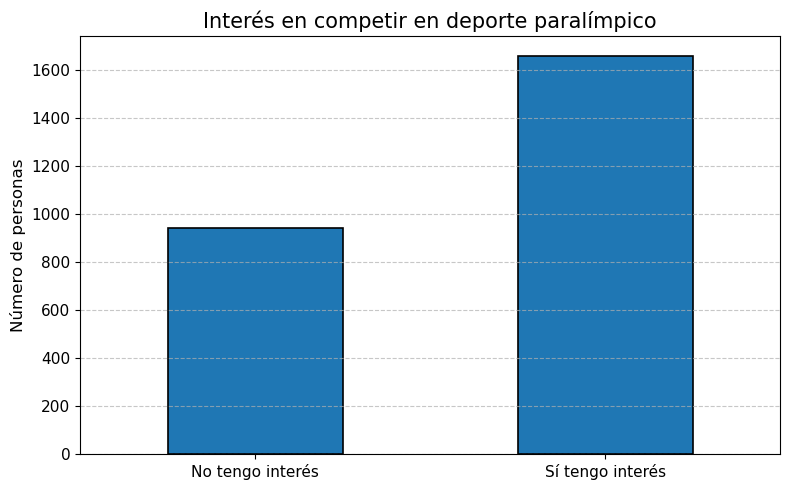

In [6]:
# -- Interés por participar en deporte paralímpico --

conteo = df["interes_competir_paralimpico"].value_counts().sort_index()

conteo.index = ["No tengo interés", "Sí tengo interés"]

fig, ax = plt.subplots(figsize=(8, 5))

conteo.plot(
    kind="bar",
    ax=ax,
    edgecolor="black",
    linewidth=1.2
)

ax.set_title("Interés en competir en deporte paralímpico", fontsize=15)
ax.set_xlabel("")
ax.set_ylabel("Número de personas", fontsize=12)

ax.tick_params(axis="both", labelsize=11)
ax.set_xticklabels(conteo.index, rotation=0)
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.7)

plt.tight_layout()

plt.savefig("graficas/interes_competir.png", dpi=300, bbox_inches="tight")

plt.show()

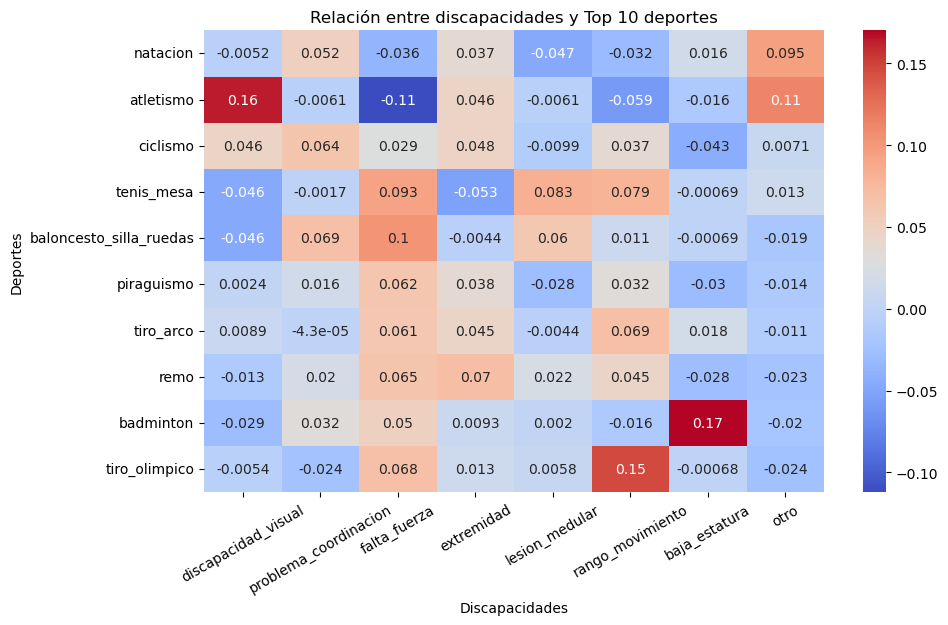

In [7]:
# -- Relación entre discapacidades y deportes con más interés --

cols_discapacidad = [
    'discapacidad_visual','problema_coordinacion','falta_fuerza',
    'extremidad','lesion_medular','rango_movimiento',
    'baja_estatura','otro'
]

cols_deportes = [
'atletismo','badminton','baloncesto_silla_ruedas','boccia','ciclismo',
'escalada','esgrima_silla_ruedas','futbol_ciegos','goalball','powerlifting',
'hipica','judo','natacion','piraguismo','remo','rugby_silla_ruedas',
'taekwondo','tenis_mesa','tenis_silla_ruedas','tiro_arco','tiro_olimpico',
'triatlon','voleibol_sentado','biatlon','curling_silla_ruedas',
'esqui_alpino','esqui_fondo','hockey_hielo','snowboard'
]

top10 = df[cols_deportes].sum().sort_values(ascending=False).head(10).index

heatmap_data = df.groupby(cols_discapacidad)[list(top10)].mean()
heatmap_data = df[list(top10) + cols_discapacidad].corr().loc[top10, cols_discapacidad]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True)

plt.title("Relación entre discapacidades y Top 10 deportes")
plt.xlabel("Discapacidades")
plt.xticks(rotation=30)
plt.ylabel("Deportes")

plt.savefig("graficas/relacion_discapacidad_deportes.png", dpi=300, bbox_inches="tight")

plt.show()

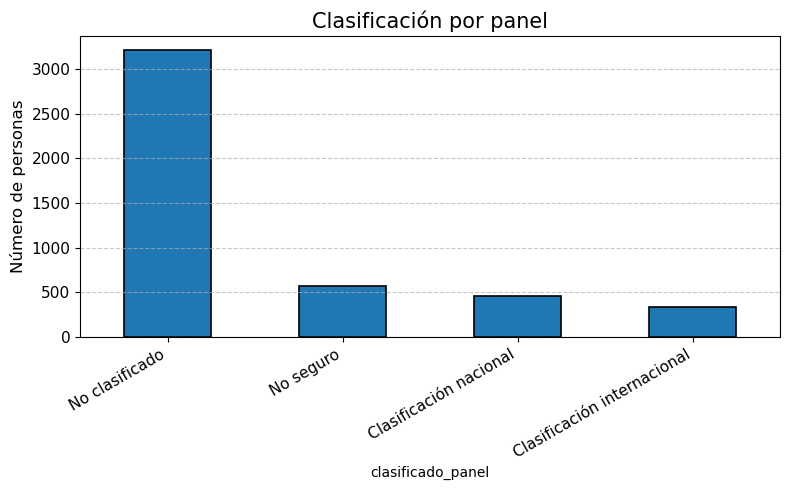

In [8]:
# -- Clasificación por panel experto --

col = "clasificado_panel"

conteo = df[col].value_counts(dropna=False)

labels = {
    0: "No clasificado",
    1: "No seguro",
    2: "Clasificación nacional",
    3: "Clasificación internacional"
}

conteo.index = conteo.index.map(lambda x: labels.get(x, "Desconocido"))

fig, ax = plt.subplots(figsize=(8, 5))

conteo.plot(
    kind="bar",
    ax=ax,
    edgecolor="black",
    linewidth=1.2
)

ax.set_title("Clasificación por panel", fontsize=15)
ax.set_ylabel("Número de personas", fontsize=12)

ax.tick_params(axis="both", labelsize=11)
ax.set_xticklabels(conteo.index, rotation=30, ha="right")
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.7)

plt.tight_layout()

plt.savefig("graficas/clasificacion_panel.png", dpi=300, bbox_inches="tight")

plt.show()

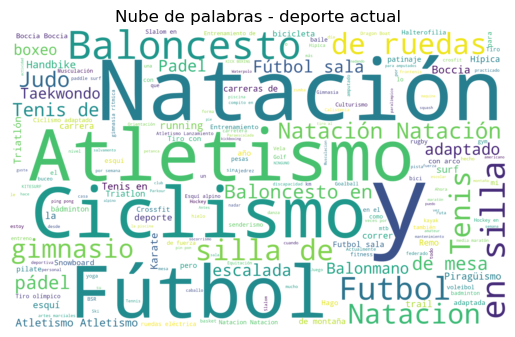

In [9]:
# -- Nube de palabras según deporte que actualmente práctican --

texto = df["deporte_actual"].dropna().astype(str)

texto = " ".join(texto)

wordcloud = WordCloud(width=2000, height=1200, background_color="white").generate(texto)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - deporte actual")

plt.savefig("graficas/nube_palabras.png", dpi=300, bbox_inches="tight")

plt.show()

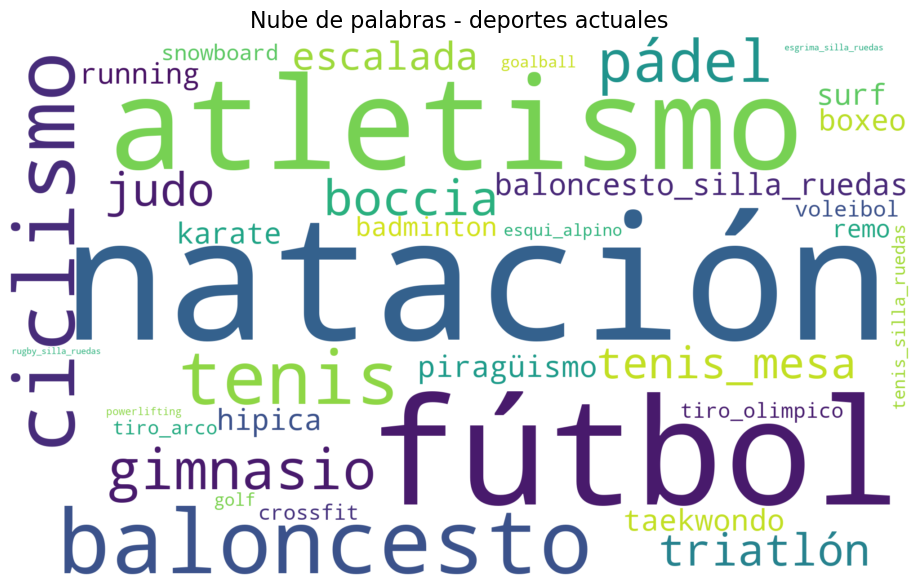

In [15]:
# -- Nube de palabras según deporte que actualmente practican (con deportes compuestos) --

import pandas as pd
import re
import unicodedata
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# lista fusionada y normalizada de deportes válidos
deportes_validos = [
    "futbol", "fútbol", "natacion", "natación", "ciclismo", "baloncesto",
    "tenis", "padel", "pádel", "running", "atletismo", "triatlon", "triatlón",
    "remo", "piraguismo", "piragüismo", "judo", "escalada", "boxeo",
    "gimnasio", "crossfit", "surf", "karate", "taekwondo",
    "voley", "voleibol", "golf",
    "badminton", "baloncesto_silla_ruedas", "boccia",
    "esgrima_silla_ruedas", "futbol_ciegos", "goalball", "powerlifting",
    "hipica", "rugby_silla_ruedas", "tenis_mesa", "tenis_silla_ruedas",
    "tiro_arco", "tiro_olimpico", "voleibol_sentado", "biatlon",
    "curling_silla_ruedas", "esqui_alpino", "esqui_fondo",
    "hockey_hielo", "snowboard"
]

# equivalencias para detectar frases reales en texto libre y mapearlas a una etiqueta limpia
alias_deportes = {
    "futbol": "fútbol",
    "fútbol": "fútbol",
    "natacion": "natación",
    "natación": "natación",
    "ciclismo": "ciclismo",
    "baloncesto": "baloncesto",
    "tenis": "tenis",
    "padel": "pádel",
    "pádel": "pádel",
    "running": "running",
    "atletismo": "atletismo",
    "triatlon": "triatlón",
    "triatlón": "triatlón",
    "remo": "remo",
    "piraguismo": "piragüismo",
    "piragüismo": "piragüismo",
    "judo": "judo",
    "escalada": "escalada",
    "boxeo": "boxeo",
    "gimnasio": "gimnasio",
    "crossfit": "crossfit",
    "surf": "surf",
    "karate": "karate",
    "taekwondo": "taekwondo",
    "voley": "voleibol",
    "voleibol": "voleibol",
    "golf": "golf",

    "badminton": "badminton",
    "bádminton": "badminton",
    "boccia": "boccia",
    "goalball": "goalball",
    "powerlifting": "powerlifting",
    "hipica": "hipica",
    "hípica": "hipica",
    "biatlon": "biatlon",
    "biatlón": "biatlon",
    "snowboard": "snowboard",

    "baloncesto en silla de ruedas": "baloncesto_silla_ruedas",
    "baloncesto_silla_ruedas": "baloncesto_silla_ruedas",

    "esgrima en silla de ruedas": "esgrima_silla_ruedas",
    "esgrima_silla_ruedas": "esgrima_silla_ruedas",

    "futbol ciegos": "futbol_ciegos",
    "fútbol ciegos": "futbol_ciegos",
    "futbol_ciegos": "futbol_ciegos",

    "rugby en silla de ruedas": "rugby_silla_ruedas",
    "rugby_silla_ruedas": "rugby_silla_ruedas",

    "tenis de mesa": "tenis_mesa",
    "tenis_mesa": "tenis_mesa",

    "tenis en silla de ruedas": "tenis_silla_ruedas",
    "tenis_silla_ruedas": "tenis_silla_ruedas",

    "tiro con arco": "tiro_arco",
    "tiro_arco": "tiro_arco",

    "tiro olimpico": "tiro_olimpico",
    "tiro olímpico": "tiro_olimpico",
    "tiro_olimpico": "tiro_olimpico",

    "voleibol sentado": "voleibol_sentado",
    "voleibol_sentado": "voleibol_sentado",

    "curling en silla de ruedas": "curling_silla_ruedas",
    "curling_silla_ruedas": "curling_silla_ruedas",

    "esqui alpino": "esqui_alpino",
    "esquí alpino": "esqui_alpino",
    "esqui_alpino": "esqui_alpino",

    "esqui de fondo": "esqui_fondo",
    "esquí de fondo": "esqui_fondo",
    "esqui_fondo": "esqui_fondo",

    "hockey sobre hielo": "hockey_hielo",
    "hockey_hielo": "hockey_hielo"
}

# ordenar patrones por longitud descendente para detectar primero los compuestos
patrones = sorted(alias_deportes.keys(), key=len, reverse=True)

def normalizar_texto(s):
    s = str(s).lower()
    s = unicodedata.normalize("NFD", s).encode("ascii", "ignore").decode("utf-8")
    s = re.sub(r"[^a-z0-9_\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extraer_deportes(texto):
    if pd.isna(texto):
        return []

    texto_norm = normalizar_texto(texto)
    encontrados = []

    for patron in patrones:
        patron_norm = normalizar_texto(patron)
        if re.search(rf"\b{re.escape(patron_norm)}\b", texto_norm):
            encontrados.append(alias_deportes[patron])

    # quitar duplicados preservando orden
    encontrados = list(dict.fromkeys(encontrados))
    return encontrados

# extraer deportes de la columna
tokens = df["deporte_actual"].dropna().apply(extraer_deportes)

# convertir a texto final
texto_final = " ".join([" ".join(lista) for lista in tokens if lista])

# generar nube
wordcloud = WordCloud(
    width=2000,
    height=1200,
    background_color="white",
    collocations=False
).generate(texto_final)

# mostrar
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - deportes actuales", fontsize=16)

plt.savefig("graficas/nube_palabras_limpia_compuestos.png", dpi=300, bbox_inches="tight")
plt.show()